In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, KFold
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from catboost import CatBoostRegressor
import lightgbm as lgb
from lightgbm import LGBMRegressor
from sklearn.feature_selection import SelectKBest, mutual_info_regression
from sklearn.model_selection import train_test_split
from tqdm import tqdm

Load the data and do a brief feature review

In [2]:
train_ds = pd.read_csv('mlurfuflat/train.csv')

In [3]:
train_ds

,id,timestamp,full_sq,life_sq,floor,state,max_floor,material,build_year,num_room,kitch_sq,full_all,sub_area,price_doc
0,13324,2013-12-23,42,28.0,8.0,2.0,9.0,1.0,1969.0,2.0,6.0,43795,Pechatniki,7100000
1,10064,2013-08-26,55,41.0,4.0,3.0,5.0,2.0,1960.0,3.0,5.0,21040,Dorogomilovo,11500000
2,12022,2013-11-11,43,29.0,4.0,2.0,5.0,2.0,1960.0,2.0,5.0,157010,Ivanovskoe,5800000
3,10186,2013-08-30,62,35.0,15.0,NaN,22.0,1.0,1985.0,2.0,10.0,178264,Jasenevo,11400000
4,30052,2015-05-29,80,55.0,15.0,1.0,24.0,6.0,2017.0,3.0,12.0,76284,Nagatinskij Zaton,12697154
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
15087,23382,2014-10-08,69,48.0,2.0,2.0,4.0,2.0,1950.0,3.0,7.0,101982,Tekstil'shhiki,9100000
15088,24264,2014-10-31,78,75.0,4.0,1.0,17.0,1.0,2014.0,3.0,1.0,247469,Nekrasovka,7722400
15089,16165,2014-03-18,38,19.0,15.0,3.0,17.0,1.0,1990.0,1.0,8.0,101708,Juzhnoportovoe,7000000
15090,10635,2013-09-20,54,32.0,11.0,3.0,16.0,1.0,1979.0,2.0,9.0,178264,Jasenevo,7000000


In [4]:
test_ds = pd.read_csv('mlurfuflat/test.csv')

In [5]:
test_ds

,id,timestamp,full_sq,life_sq,floor,state,max_floor,material,build_year,num_room,kitch_sq,full_all,sub_area
0,1417,2012-03-03,51,31.0,16.0,NaN,NaN,NaN,NaN,NaN,NaN,221709,Krjukovo
1,9725,2013-08-08,44,29.0,5.0,3.0,9.0,1.0,1969.0,2.0,5.0,37502,Sviblovo
2,30369,2015-06-23,32,18.0,1.0,3.0,9.0,1.0,1970.0,1.0,6.0,125354,Chertanovo Severnoe
3,20522,2014-07-02,51,30.0,11.0,1.0,17.0,1.0,2003.0,2.0,9.0,130229,Moskvorech'e-Saburovo
4,12891,2013-12-07,44,28.0,4.0,2.0,5.0,1.0,1965.0,2.0,5.0,145576,Caricyno
...,...,...,...,...,...,...,...,...,...,...,...,...,...
3769,10843,2013-09-30,53,28.0,9.0,3.0,16.0,5.0,1976.0,2.0,11.0,1318695,Vyhino-Zhulebino
3770,543,2011-12-06,31,17.0,5.0,NaN,NaN,NaN,NaN,NaN,NaN,85083,Sokolinaja Gora
3771,25332,2014-11-26,38,19.0,8.0,3.0,16.0,1.0,1977.0,1.0,10.0,111023,Ochakovo-Matveevskoe
3772,25329,2014-11-26,120,57.0,7.0,3.0,10.0,2.0,1985.0,3.0,11.0,47245,Meshhanskoe


In [6]:
macro = pd.read_csv('mlurfuflat/macro.csv')

In [7]:
macro

,timestamp,salary,fixed_basket,rent_price_3room_eco,rent_price_2room_eco,rent_price_1room_eco,average_life_exp
0,2010-01-01,38410.5,11443.63,NaN,NaN,NaN,74.2
1,2010-01-02,38410.5,11443.63,NaN,NaN,NaN,74.2
2,2010-01-03,38410.5,11443.63,NaN,NaN,NaN,74.2
3,2010-01-04,38410.5,11443.63,NaN,NaN,NaN,74.2
4,2010-01-05,38410.5,11443.63,NaN,NaN,NaN,74.2
...,...,...,...,...,...,...,...
2479,2016-10-15,NaN,20354.78,45.71,38.4,29.78,NaN
2480,2016-10-16,NaN,20354.78,45.71,38.4,29.78,NaN
2481,2016-10-17,NaN,20354.78,45.71,38.4,29.78,NaN
2482,2016-10-18,NaN,20354.78,45.71,38.4,29.78,NaN


Visualize distributions and outliers

In [8]:
class Visualizer:
    """Data visualization."""

    @staticmethod
    def plot_boxplots_outliers(train_ds):
        """Create boxplots for outlier analysis."""
        columns_num = ['full_sq', 'kitch_sq', 'life_sq', 'floor', 'state', 'max_floor', 'num_room', 'material', 'full_all']
        for column in columns_num:
            plt.figure(figsize=(10, 6))
            sns.boxplot(y=column, data=train_ds)
            plt.title(column)
            plt.tight_layout()
            plt.show()

    @staticmethod
    def plot_histograms(train_ds):
        """Create histograms of feature distributions."""
        numeric_cols = train_ds.select_dtypes(include=[np.number]).columns.tolist()
        for col in ['id', 'timestamp', 'price_doc']:
            if col in numeric_cols:
                numeric_cols.remove(col)

        if len(numeric_cols) > 0:
            train_ds[numeric_cols].hist(bins=50, figsize=(25, 20))
            plt.tight_layout()
            plt.show()

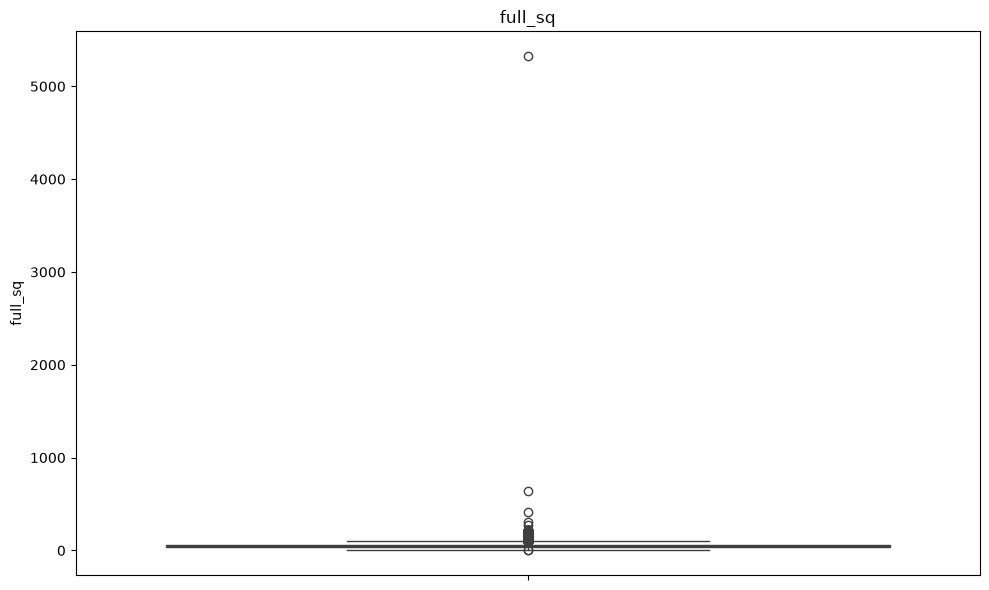

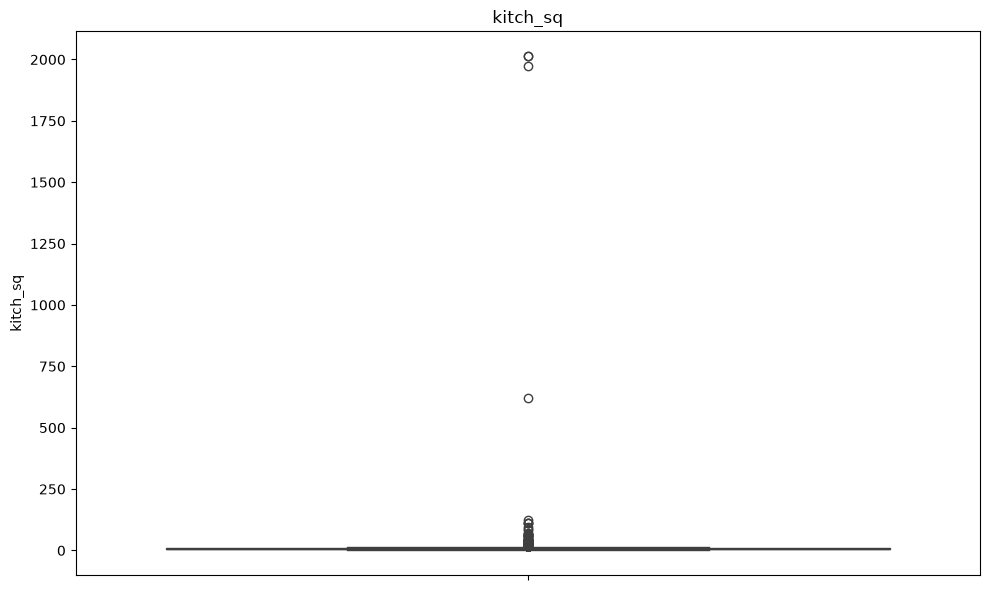

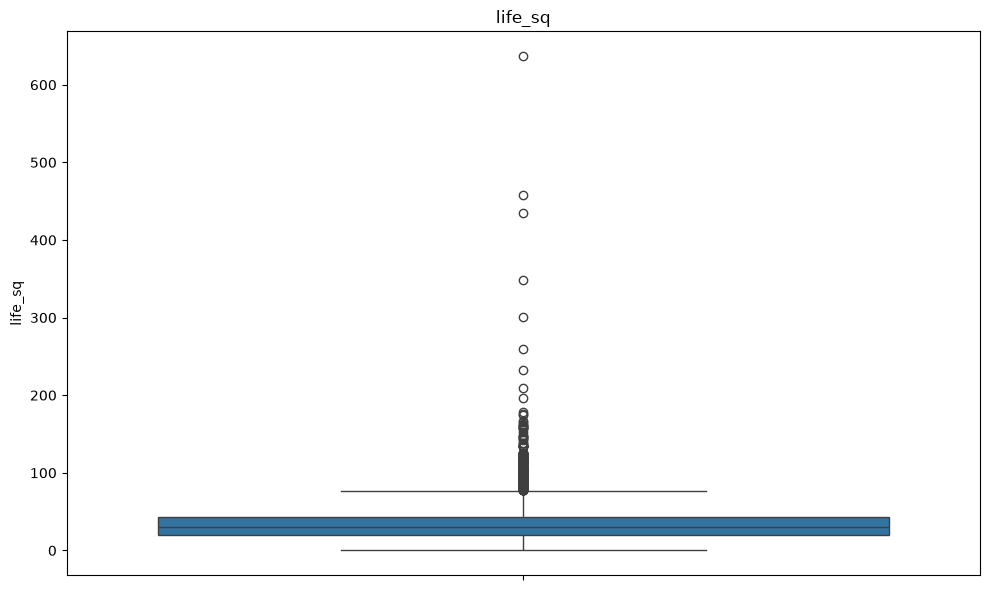

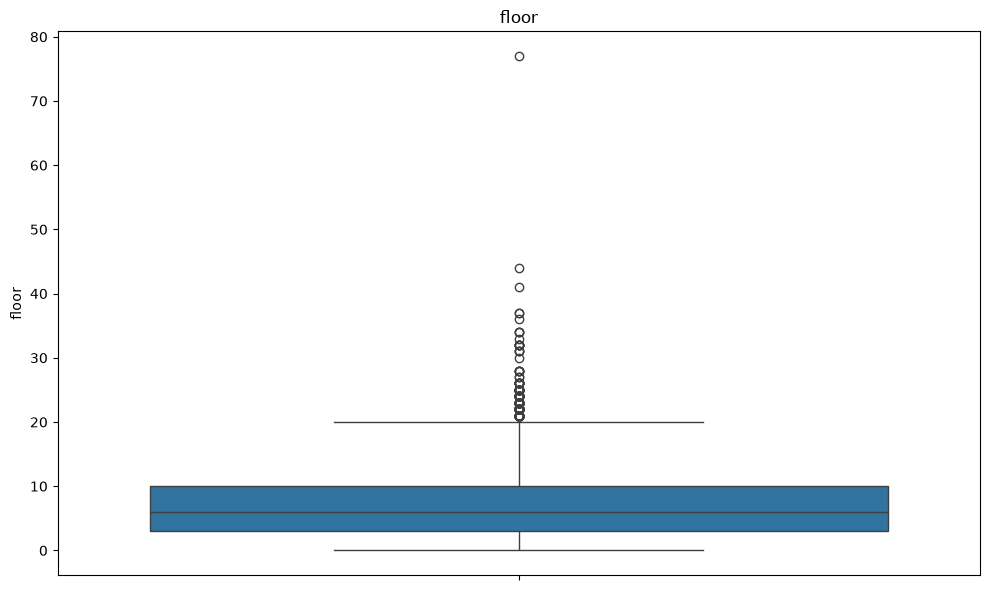

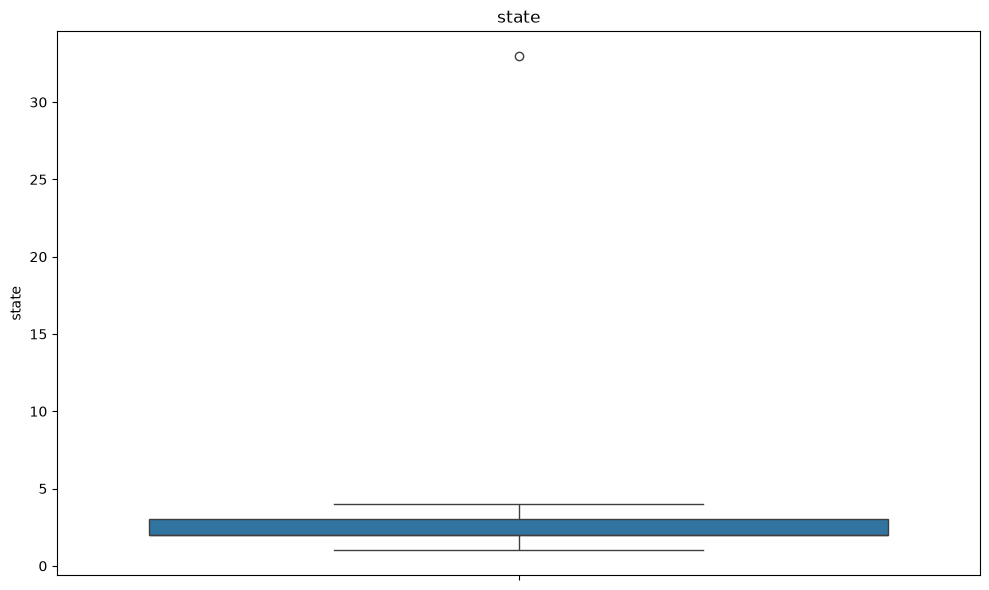

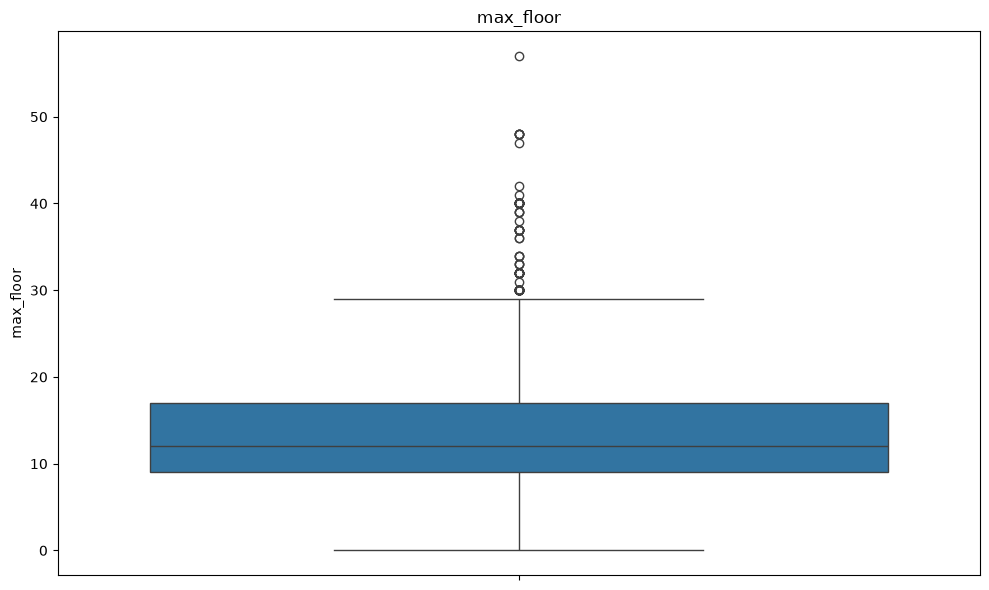

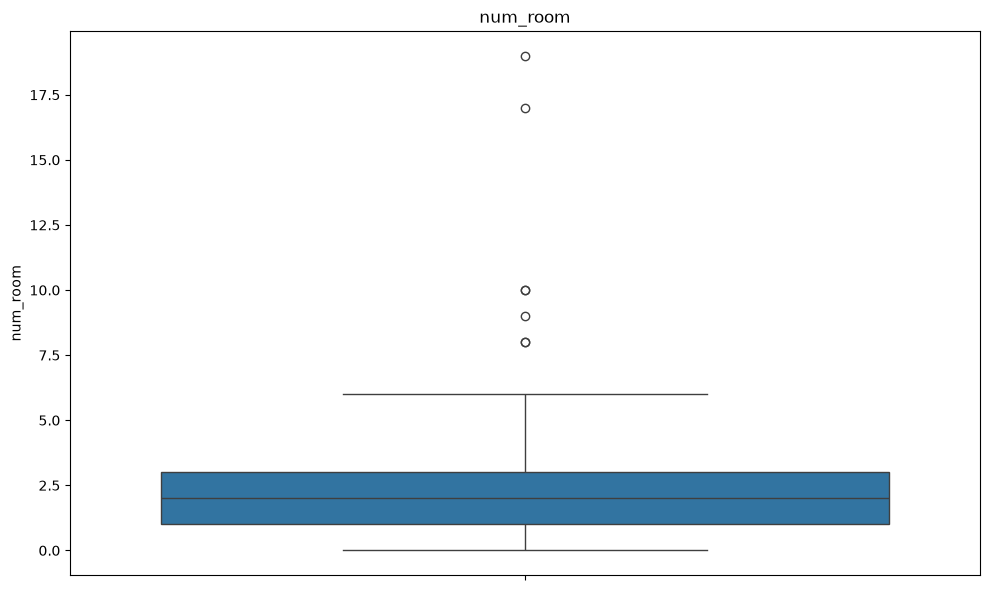

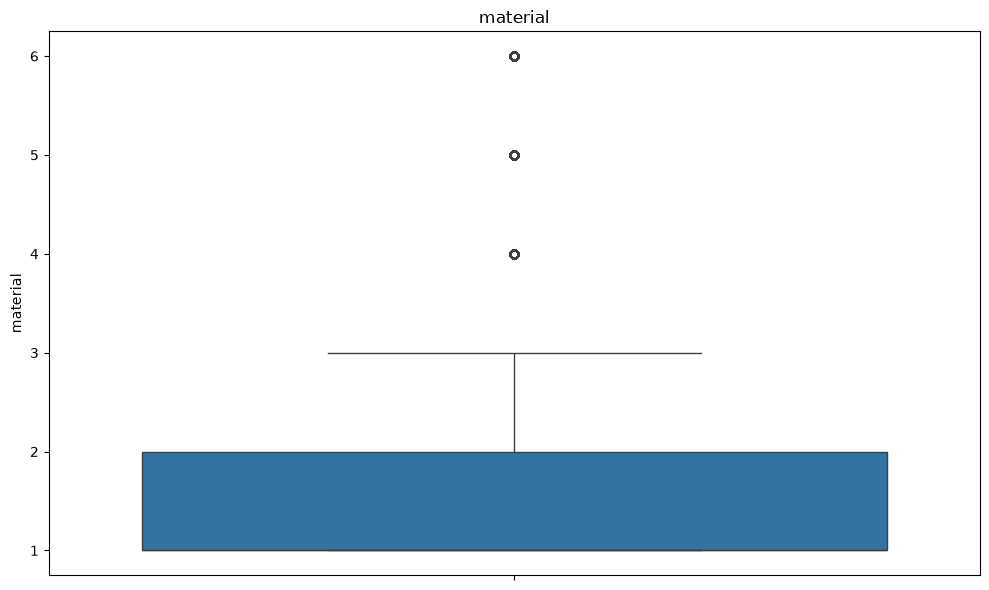

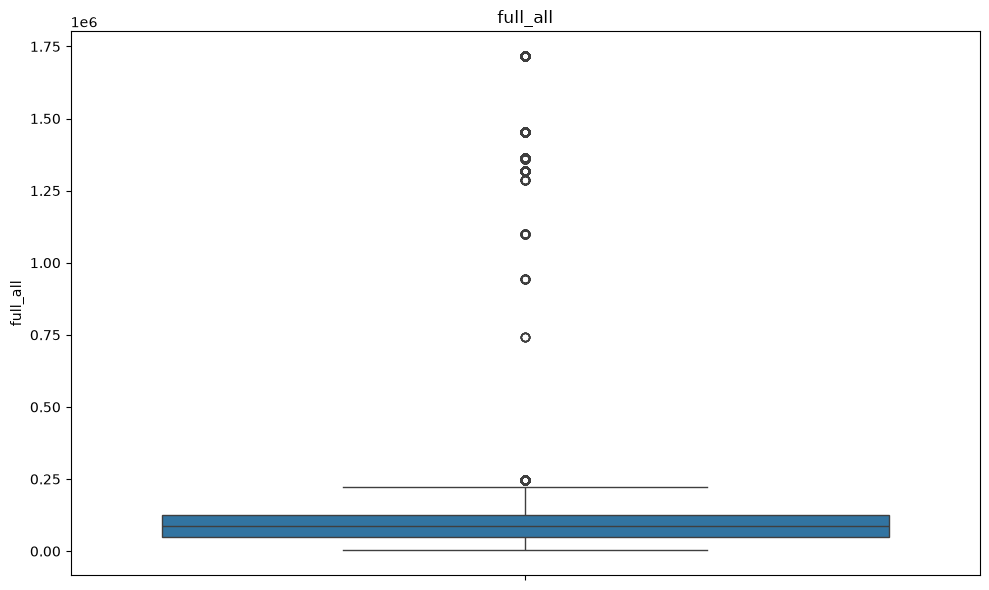

In [9]:
Visualizer.plot_boxplots_outliers(train_ds)

Let's look at the distributions


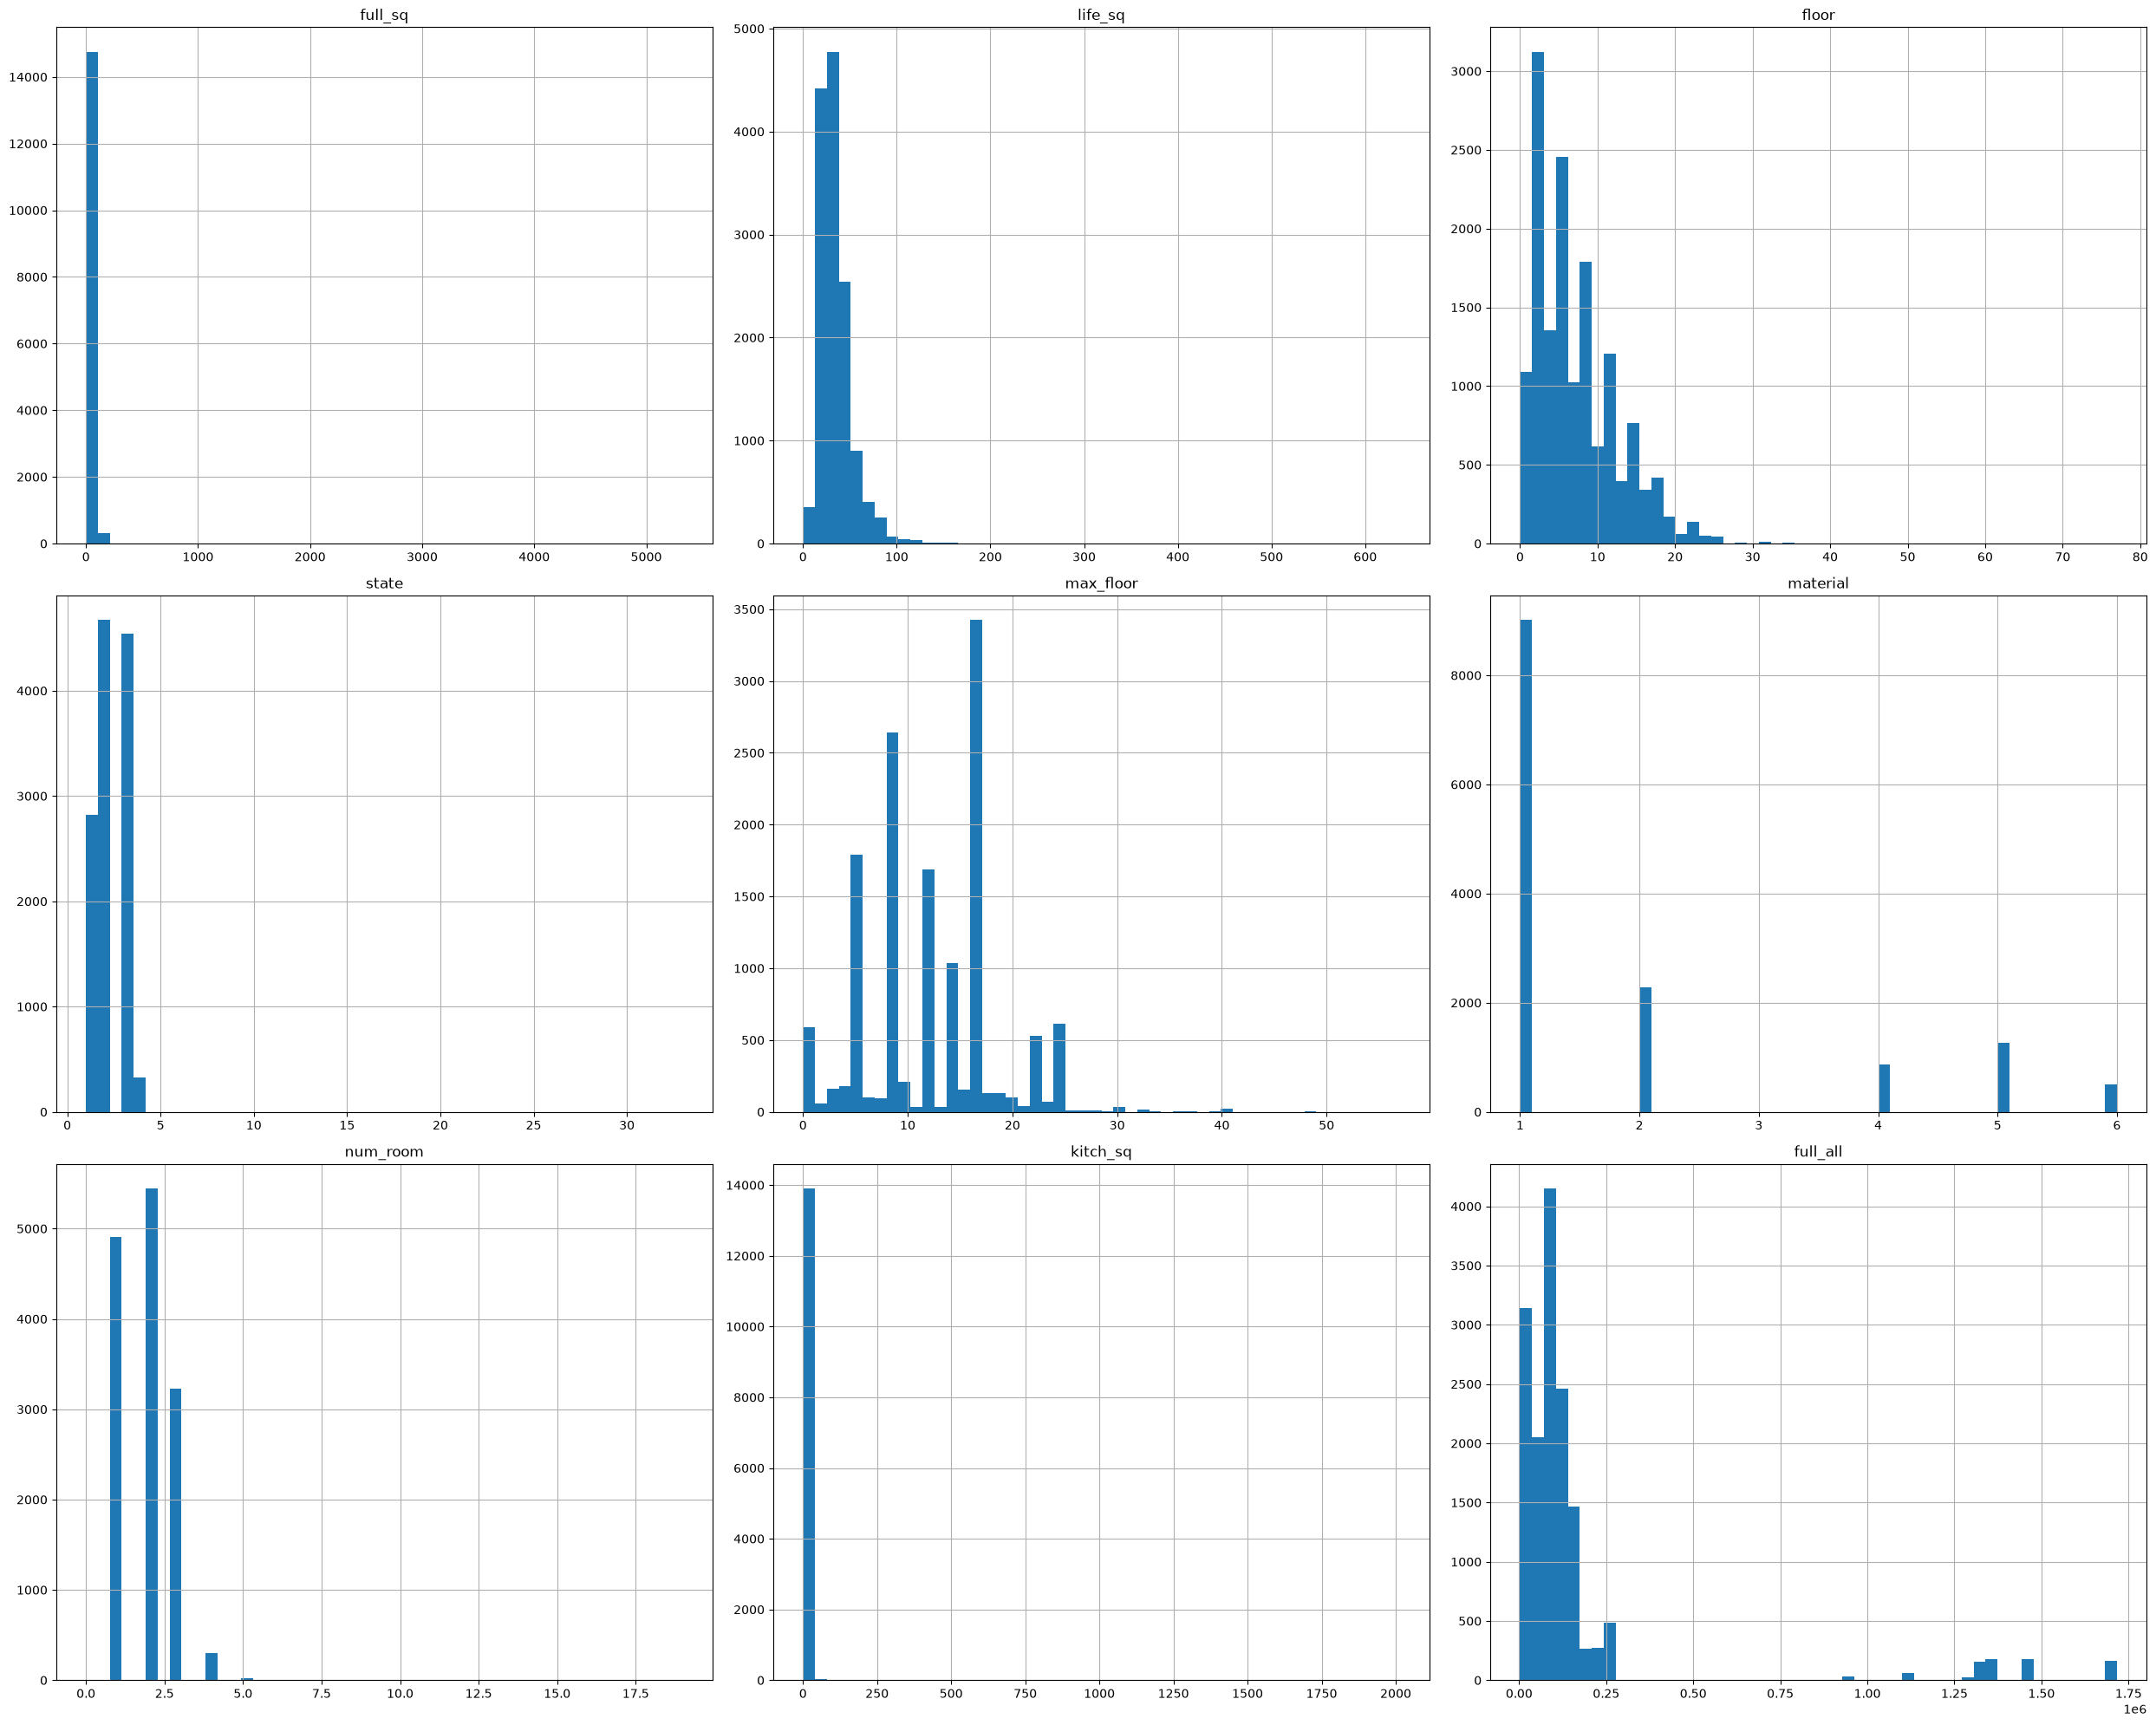

In [10]:
Visualizer.plot_histograms(train_ds)

Most features have different scales and skewed distributions

Some features will need log transformation

In [11]:
train_ds.columns

Index(['id', 'timestamp', 'full_sq', 'life_sq', 'floor', 'state', 'max_floor',
       'material', 'build_year', 'num_room', 'kitch_sq', 'full_all',
       'sub_area', 'price_doc'],
      dtype='str')

Let's look at the statistics

In [12]:
train_ds.describe()

,id,full_sq,life_sq,floor,state,max_floor,material,num_room,kitch_sq,full_all,price_doc
count,15092.000000,15092.000000,13828.000000,15069.000000,12366.000000,13938.000000,13938.000000,13938.000000,13938.00000,1.509200e+04,1.509200e+04
mean,18772.427710,53.967002,33.784929,7.283297,2.194889,12.419142,1.895824,1.934783,7.28060,1.592291e+05,7.564667e+06
std,7102.906802,48.081978,19.794406,5.194017,0.860994,6.264204,1.511353,0.865651,30.07194,3.037953e+05,4.985187e+06
min,15.000000,0.000000,0.000000,0.000000,1.000000,0.000000,1.000000,0.000000,0.00000,2.546000e+03,3.314640e+05
25%,13464.750000,38.000000,20.000000,3.000000,2.000000,9.000000,1.000000,1.000000,5.00000,4.843900e+04,5.100000e+06
50%,19005.500000,49.000000,30.000000,6.000000,2.000000,12.000000,1.000000,2.000000,7.00000,8.771300e+04,6.650000e+06
75%,24746.250000,63.000000,43.000000,10.000000,3.000000,17.000000,2.000000,3.000000,9.00000,1.253540e+05,8.900000e+06
max,30473.000000,5326.000000,637.000000,77.000000,33.000000,57.000000,6.000000,19.000000,2014.00000,1.716730e+06,9.512250e+07


Clear outliers, missing values, and invalid entries are observed. full_sq, kitch_sq, and life_sq have high maximum area values; preprocessing will be required

In [13]:
train_ds.info()

<class 'pandas.DataFrame'>
RangeIndex: 15092 entries, 0 to 15091
Data columns (total 14 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   id          15092 non-null  int64  
 1   timestamp   15092 non-null  str    
 2   full_sq     15092 non-null  int64  
 3   life_sq     13828 non-null  float64
 4   floor       15069 non-null  float64
 5   state       12366 non-null  float64
 6   max_floor   13938 non-null  float64
 7   material    13938 non-null  float64
 8   build_year  13475 non-null  str    
 9   num_room    13938 non-null  float64
 10  kitch_sq    13938 non-null  float64
 11  full_all    15092 non-null  int64  
 12  sub_area    15092 non-null  str    
 13  price_doc   15092 non-null  int64  
dtypes: float64(7), int64(4), str(3)
memory usage: 1.6 MB


We also see missing values to handle; timestamp and build_year need their data types changed

Below is the production pipeline after major refactoring. The full pipeline is invoked at the very end

**Preprocessing. What will be implemented next:**

Data type conversion (type_data):

timestamp -> datetime

Numeric columns (full_sq, life_sq, floor, max_floor, build_year, num_room, kitch_sq, state, price_doc) -> numeric

Categorical columns (sub_area, product_type, material, ecology) -> category

Anomaly correction (fix_anomalies):

full_sq < 10 -> NaN

num_room <= 0 -> NaN

max_floor == 0 -> NaN

Area logic correction (fix_area_logic):

If life_sq + kitch_sq > full_sq, then full_sq = life_sq + kitch_sq

Floor logic correction (fix_floor_logic):

If floor > max_floor, then max_floor = floor

Missing value imputation for full_sq (fill_full_sq_smart):

First: if life_sq and kitch_sq exist, full_sq = life_sq + kitch_sq

Then (if some feature is missing for a given listing): median by district (sub_area)

Finally: global median

Missing value imputation for build_year (fill_build_year_smart):

Median by district (sub_area)

Then: global median

Missing value imputation for max_floor (fill_max_floor_by_area):

Median by district (sub_area)

Then: global median

Missing value imputation for life_sq and kitch_sq (fill_life_kitch_by_ratio):

Median ratios by district are computed: life_ratio = life_sq / full_sq, kitch_ratio = kitch_sq / full_sq

Imputation: life_sq = full_sq * life_ratio[sub_area], kitch_sq = full_sq * kitch_ratio[sub_area]

Missing value imputation for num_room (fill_num_room_smart):

First: median by district (sub_area)

Then: median by area bin (full_sq_bin)

Finally: global median

Categorical feature imputation (fill_categorical_by_mode):

material: mode by district, then global mode

state: mode by district, then global mode

In [14]:
class DataPreprocessor:
    """Basic data preprocessing."""

    @staticmethod
    def add_full_sq_bin_column(df):
        """Create categorical feature full_sq_bin based on total area."""
        bins = [0, 30, 50, 70, 90, 120, np.inf]
        labels = ['0-30', '30-50', '50-70', '70-90', '90-120', '120+']
        df['full_sq_bin'] = pd.cut(df['full_sq'], bins=bins, labels=labels, include_lowest=True)
        return df

    @staticmethod
    def type_data(df):
        """Convert data types: timestamp to datetime, numeric and categorical columns to appropriate types."""
        df['timestamp'] = pd.to_datetime(df['timestamp'])
        numeric_cols = ['full_sq', 'life_sq', 'floor', 'max_floor', 'build_year', 
                       'num_room', 'kitch_sq', 'state', 'price_doc']
        for col in numeric_cols:
            if col in df.columns:
                df[col] = pd.to_numeric(df[col], errors='coerce')
        categorical_cols = ['sub_area', 'product_type', 'material', 'ecology']
        for col in categorical_cols:
            if col in df.columns:
                df[col] = df[col].astype('category')
        return df

In [15]:
class DataFixer:
    """Fix anomalies in the data."""

    @staticmethod
    def fix_anomalies(df, dataset_name=""):
        """Fix anomalous values: full_sq < 10, num_room <= 0, max_floor == 0."""
        df_result = df.copy()
        anomaly_count = 0
        mask_full_sq = df_result['full_sq'] < 10
        count_full_sq = mask_full_sq.sum()
        if count_full_sq > 0:
            df_result.loc[mask_full_sq, 'full_sq'] = np.nan
            anomaly_count += count_full_sq
            print(f"[{dataset_name}] full_sq < 10 -> NaN: {count_full_sq} cases")

        mask_num_room = df_result['num_room'] <= 0
        count_num_room = mask_num_room.sum()
        if count_num_room > 0:
            df_result.loc[mask_num_room, 'num_room'] = np.nan
            anomaly_count += count_num_room
            print(f"[{dataset_name}] num_room <= 0 -> NaN: {count_num_room} cases")

        mask_max_floor = df_result['max_floor'] == 0
        count_max_floor = mask_max_floor.sum()
        if count_max_floor > 0:
            df_result.loc[mask_max_floor, 'max_floor'] = np.nan
            anomaly_count += count_max_floor
            print(f"[{dataset_name}] max_floor == 0 -> NaN: {count_max_floor} cases")

        if anomaly_count == 0:
            print(f"[{dataset_name}] No anomalies found")
        return df_result

    @staticmethod
    def fix_area_logic(df, dataset_name=""):
        """Fix area logic: if life_sq + kitch_sq > full_sq, set full_sq = life_sq + kitch_sq."""
        if not all(col in df.columns for col in ['full_sq', 'life_sq', 'kitch_sq']):
            return df
        df_result = df.copy()
        invalid_mask = (df_result['life_sq'] + df_result['kitch_sq']) > df_result['full_sq']
        invalid_count = invalid_mask.sum()
        if invalid_count > 0:
            df_result.loc[invalid_mask, 'full_sq'] = (
                df_result.loc[invalid_mask, 'life_sq'] + 
                df_result.loc[invalid_mask, 'kitch_sq']
            )
            print(f"[{dataset_name}] Fixed {invalid_count} full_sq values")
        return df_result

    @staticmethod
    def fix_floor_logic(df, dataset_name=""):
        """Fix floor logic: if floor > max_floor, set max_floor = floor."""
        if 'floor' not in df.columns or 'max_floor' not in df.columns:
            return df
        df_result = df.copy()
        invalid_mask = df_result['floor'] > df_result['max_floor']
        invalid_count = invalid_mask.sum()
        if invalid_count > 0:
            df_result.loc[invalid_mask, 'max_floor'] = df_result.loc[invalid_mask, 'floor']
            print(f"[{dataset_name}] Fixed {invalid_count} floor values")
        return df_result

In [16]:
class MissingValueImputer:
    """Missing value imputation."""

    @staticmethod
    def fill_build_year_smart(df_train, df_test):
        """Fill build_year with district median, then global median."""
        df_train_result = df_train.copy()
        df_test_result = df_test.copy()
        area_medians = df_train_result.groupby('sub_area', observed=True)['build_year'].median()
        for area in df_test_result['sub_area'].unique():
            mask = (df_test_result['sub_area'] == area) & (df_test_result['build_year'].isna())
            if mask.sum() > 0 and area in area_medians.index:
                df_test_result.loc[mask, 'build_year'] = area_medians[area]
        global_median = df_train_result['build_year'].median()
        df_test_result['build_year'] = df_test_result['build_year'].fillna(global_median)
        return df_train_result, df_test_result

    @staticmethod
    def fill_max_floor_by_area(df_train, df_test):
        """Fill max_floor with district median, then global median."""
        df_train_result = df_train.copy()
        df_test_result = df_test.copy()
        area_medians = df_train_result.groupby('sub_area', observed=True)['max_floor'].median()
        for area in df_test_result['sub_area'].unique():
            mask = (df_test_result['sub_area'] == area) & (df_test_result['max_floor'].isna())
            if mask.sum() > 0 and area in area_medians.index:
                df_test_result.loc[mask, 'max_floor'] = area_medians[area]
        global_median = df_train_result['max_floor'].median()
        df_test_result['max_floor'] = df_test_result['max_floor'].fillna(global_median)
        return df_train_result, df_test_result

    @staticmethod
    def fill_life_kitch_by_ratio(df_train, df_test):
        """Fill life_sq and kitch_sq using district median ratios."""
        df_train_result = df_train.copy()
        df_test_result = df_test.copy()
        df_train_result['life_ratio'] = df_train_result['life_sq'] / df_train_result['full_sq']
        df_train_result['kitch_ratio'] = df_train_result['kitch_sq'] / df_train_result['full_sq']
        area_life_ratio = df_train_result.groupby('sub_area', observed=True)['life_ratio'].median()
        area_kitch_ratio = df_train_result.groupby('sub_area', observed=True)['kitch_ratio'].median()
        for area in df_test_result['sub_area'].unique():
            mask = (df_test_result['sub_area'] == area) & (df_test_result['life_sq'].isna())
            if mask.sum() > 0 and area in area_life_ratio.index:
                df_test_result.loc[mask, 'life_sq'] = df_test_result.loc[mask, 'full_sq'] * area_life_ratio[area]
        for area in df_test_result['sub_area'].unique():
            mask = (df_test_result['sub_area'] == area) & (df_test_result['kitch_sq'].isna())
            if mask.sum() > 0 and area in area_kitch_ratio.index:
                df_test_result.loc[mask, 'kitch_sq'] = df_test_result.loc[mask, 'full_sq'] * area_kitch_ratio[area]
        return df_train_result, df_test_result

    @staticmethod
    def fill_categorical_by_mode(df_train, df_test, column):
        """Fill categorical column with district mode, then global mode."""
        df_train_result = df_train.copy()
        df_test_result = df_test.copy()
        area_modes = df_train_result.groupby('sub_area', observed=True)[column].agg(lambda x: x.mode()[0] if len(x.mode()) > 0 else np.nan)
        for area in df_test_result['sub_area'].unique():
            mask = (df_test_result['sub_area'] == area) & (df_test_result[column].isna())
            if mask.sum() > 0 and area in area_modes.index:
                df_test_result.loc[mask, column] = area_modes[area]
        global_mode = df_train_result[column].mode()[0] if len(df_train_result[column].mode()) > 0 else df_train_result[column].median()
        df_test_result[column] = df_test_result[column].fillna(global_mode)
        return df_train_result, df_test_result

    @staticmethod
    def fill_full_sq_smart(df_train, df_test):
        """Fill full_sq: first life_sq + kitch_sq, then district median, then global median."""
        df_train_result = df_train.copy()
        df_test_result = df_test.copy()
        mask_calc = (df_test_result['full_sq'].isna()) & (df_test_result['life_sq'].notna()) & (df_test_result['kitch_sq'].notna())
        df_test_result.loc[mask_calc, 'full_sq'] = df_test_result.loc[mask_calc, 'life_sq'] + df_test_result.loc[mask_calc, 'kitch_sq']
        area_medians = df_train_result.groupby('sub_area', observed=True)['full_sq'].median()
        for area in df_test_result['sub_area'].unique():
            mask = (df_test_result['sub_area'] == area) & (df_test_result['full_sq'].isna())
            if mask.sum() > 0 and area in area_medians.index:
                df_test_result.loc[mask, 'full_sq'] = area_medians[area]
        global_median = df_train_result['full_sq'].median()
        df_test_result['full_sq'] = df_test_result['full_sq'].fillna(global_median)
        return df_train_result, df_test_result

    @staticmethod
    def fill_num_room_smart(df_train, df_test):
        """Fill num_room with district median, then full_sq_bin median, then global median."""
        df_train_result = df_train.copy()
        df_test_result = df_test.copy()
        area_medians = df_train_result.groupby('sub_area', observed=True)['num_room'].median()
        for area in df_test_result['sub_area'].unique():
            mask = (df_test_result['sub_area'] == area) & (df_test_result['num_room'].isna())
            if mask.sum() > 0 and area in area_medians.index:
                df_test_result.loc[mask, 'num_room'] = area_medians[area]
        df_train_result = DataPreprocessor.add_full_sq_bin_column(df_train_result)
        df_test_result = DataPreprocessor.add_full_sq_bin_column(df_test_result)
        bin_medians = df_train_result.groupby('full_sq_bin', observed=True)['num_room'].median()
        for bin_val in df_test_result['full_sq_bin'].unique():
            mask = (df_test_result['full_sq_bin'] == bin_val) & (df_test_result['num_room'].isna())
            if mask.sum() > 0 and bin_val in bin_medians.index:
                df_test_result.loc[mask, 'num_room'] = bin_medians[bin_val]
        global_median = df_train_result['num_room'].median()
        df_test_result['num_room'] = df_test_result['num_room'].fillna(global_median)
        return df_train_result, df_test_result

In [17]:
class DataPreprocessingPipeline:
    """
    Full data preprocessing pipeline.
    
    Combines all preprocessing steps:
    - Data type conversion
    - Anomaly correction (area, floor)
    - Missing value imputation
    """

    @staticmethod
    def process_dataset(train_ds, test_ds):
        """Run full preprocessing: types, anomaly correction, missing value imputation."""
        train_ds = DataPreprocessor.type_data(train_ds)
        test_ds = DataPreprocessor.type_data(test_ds)
        train_ds = DataFixer.fix_anomalies(train_ds, "TRAIN")
        test_ds = DataFixer.fix_anomalies(test_ds, "TEST")
        train_ds = DataFixer.fix_area_logic(train_ds, "TRAIN")
        test_ds = DataFixer.fix_area_logic(test_ds, "TEST")
        train_ds = DataFixer.fix_floor_logic(train_ds, "TRAIN")
        test_ds = DataFixer.fix_floor_logic(test_ds, "TEST")
        train_ds, test_ds = MissingValueImputer.fill_full_sq_smart(train_ds, test_ds)
        train_ds, test_ds = MissingValueImputer.fill_build_year_smart(train_ds, test_ds)
        train_ds, test_ds = MissingValueImputer.fill_max_floor_by_area(train_ds, test_ds)
        train_ds, test_ds = MissingValueImputer.fill_life_kitch_by_ratio(train_ds, test_ds)
        train_ds, test_ds = MissingValueImputer.fill_num_room_smart(train_ds, test_ds)
        train_ds, test_ds = MissingValueImputer.fill_categorical_by_mode(train_ds, test_ds, 'material')
        train_ds, test_ds = MissingValueImputer.fill_categorical_by_mode(train_ds, test_ds, 'state')
        return train_ds, test_ds



**Feature engineering. What will be implemented next:**

Add district popularity (add_district_popularity) — number of listings per district

Add macro and engineered features (add_engineered_features):

Macro features: rent prices, salary, consumer basket, life expectancy, salary_to_basket
Engineered features: building_age, building_age_category, sq_per_room, kitch_sq_ratio, life_sq_ratio, floor_ratio, is_first_floor, is_last_floor, is_middle_floor, log_full_sq, log_building_age, area_age_ratio, area_floor_interaction, room_floor_ratio

Final feature preparation (prepare_features):

Target encoding + Bayesian smoothing for sub_area (alpha=10), for rare districts

District aggregates: log_sub_area_price_median, log_sub_area_price_mean, sub_area_count

Additional: room_size, full_sq_bin (area-based categorization)

Target variable: y_train = log1p(price_doc)

Feature selection (FeatureSelector):

Method 1: select_manual (used in the pipeline):

Remove duplicate/correlated features: if both log_X and X exist, keep only log_X

Method 2: select_by_model_importance (can be called with train_with_feature_selection, but not used because it was unstable and often hurt predictions):

Trains a CatBoost model to obtain feature importance

Filters out features with importance ≤ 0.1 (default threshold)

Returns filtered features and updated categorical feature indices

Categorical feature preparation (prepare_categorical_features):

Convert material, state, full_sq_bin to int for CatBoost

Fill NaN in material and full_sq_bin with mode

In [18]:
class FeatureEngineer:
    """Feature creation."""

    @staticmethod
    def add_district_popularity(train_df, test_df):
        """Add district popularity feature (number of listings)."""
        district_counts = train_df['sub_area'].value_counts()
        train_df['district_popularity'] = train_df['sub_area'].map(district_counts)
        test_df['district_popularity'] = test_df['sub_area'].map(district_counts)
        test_df['district_popularity'] = test_df['district_popularity'].fillna(district_counts.median())
        return train_df, test_df

    @staticmethod
    def add_engineered_features(train_data, test_data, macro_df):
        """Add macro features and create new engineered features."""
        macro_features = macro_df.copy()
        macro_features['timestamp'] = pd.to_datetime(macro_features['timestamp'])
        macro_features['year'] = macro_features['timestamp'].dt.year
        macro_cols = ['rent_price_1room_eco', 'rent_price_2room_eco', 'rent_price_3room_eco', 
                     'average_life_exp', 'salary', 'fixed_basket']
        for col in ['salary', 'fixed_basket', 'average_life_exp']:
            if col in macro_features.columns:
                yearly_medians = macro_features.groupby('year', observed=True)[col].transform('median')
                macro_features[col] = macro_features[col].fillna(yearly_medians)
        if 'salary' in macro_features.columns and 'fixed_basket' in macro_features.columns:
            macro_features['salary_to_basket'] = macro_features['salary'] / macro_features['fixed_basket'].replace({0: np.nan})
        rename_dict = {}
        for col in macro_cols + ['salary_to_basket']:
            if col in macro_features.columns:
                rename_dict[col] = f'macro_{col}'
        macro_features = macro_features.rename(columns=rename_dict)
        for col in macro_features.columns:
            if col.startswith('macro_') and macro_features[col].dtype in ['float64', 'int64']:
                macro_features[col] = macro_features[col].interpolate(method='linear', limit_direction='both')
        train_data = train_data.merge(macro_features, on='timestamp', how='left')
        test_data = test_data.merge(macro_features, on='timestamp', how='left')
        for df in [train_data, test_data]:
            df['sale_year'] = df['timestamp'].dt.year
            df['building_age'] = (df['sale_year'] - df['build_year']).clip(lower=0)
            df['building_age_category'] = pd.cut(df['building_age'], bins=[-np.inf, 10, 100, np.inf], labels=[0, 1, 2])
            df['building_age_category'] = df['building_age_category'].cat.codes
            df.loc[df['building_age_category'] == -1, 'building_age_category'] = 1


            df['sq_per_room'] = df['full_sq'] / df['num_room']
            df['kitch_sq_ratio'] = df['kitch_sq'] / df['full_sq']
            df['life_sq_ratio'] = df['life_sq'] / df['full_sq']
            df['kitch_sq_ratio'] = df['kitch_sq_ratio'].clip(lower=0, upper=1)
            df['life_sq_ratio'] = df['life_sq_ratio'].clip(lower=0, upper=1)
            df['floor_ratio'] = df['floor'] / df['max_floor']
            df['is_first_floor'] = (df['floor'] == 1).astype(int)
            df['is_last_floor'] = (df['floor'] == df['max_floor']).astype(int)
            df['is_middle_floor'] = ((df['floor'] > 1) & (df['floor'] < df['max_floor'])).astype(int)
            df['log_full_sq'] = np.log1p(df['full_sq'])
            df['log_building_age'] = np.log1p(df['building_age'])
            df['area_age_ratio'] = df['full_sq'] / (df['building_age'] + 1)
            df['area_floor_interaction'] = df['full_sq'] * df['floor_ratio']
            df['room_floor_ratio'] = df['num_room'] / (df['floor'] + 1)

        return train_data, test_data

    @staticmethod
    def prepare_categorical_features(X_train, X_test):
        """Prepare categorical features for CatBoost: convert to int."""
        if 'full_sq_bin' in X_train.columns:
            X_train['full_sq_bin'] = X_train['full_sq_bin'].astype('category')
            X_test['full_sq_bin'] = X_test['full_sq_bin'].astype('category')

        # convert categoricals to int for CatBoost
        for col in X_train.columns:
            if X_train[col].dtype.name == 'category':
                X_train[col] = X_train[col].cat.codes
                X_test[col] = X_test[col].cat.codes
                if (X_train[col] == -1).any():
                    mode_val = X_train[X_train[col] != -1][col].mode()
                    fill_val = int(mode_val[0]) if len(mode_val) > 0 else 0
                    X_train.loc[X_train[col] == -1, col] = fill_val
                    X_test.loc[X_test[col] == -1, col] = fill_val
                X_train[col] = X_train[col].astype(int)
                X_test[col] = X_test[col].astype(int)

        # identify categorical features for CatBoost
        cat_features = []
        for col in ['material', 'state', 'full_sq_bin']:
            if col in X_train.columns:
                cat_features.append(X_train.columns.get_loc(col))

        for idx in cat_features:
            col_name = X_train.columns[idx]
            if X_train[col_name].dtype != 'int64':
                X_train[col_name] = X_train[col_name].astype(int)
            if X_test[col_name].dtype != 'int64':
                X_test[col_name] = X_test[col_name].astype(int)
        
        return X_train, X_test, cat_features

    @staticmethod
    def prepare_features(train_data, test_data):
        """Prepare final features: target encoding, district aggregates, feature selection."""
        feature_columns = [
            'full_sq', 'life_sq', 'floor', 'max_floor', 'build_year', 'num_room',
            'kitch_sq', 'state', 'material', 'sale_year',
            'building_age', 'sq_per_room', 'kitch_sq_ratio', 'life_sq_ratio',
            'floor_ratio', 'is_first_floor', 'is_last_floor', 'is_middle_floor',
            'log_full_sq', 'log_building_age', 'area_age_ratio',
            'area_floor_interaction', 'room_floor_ratio', 'district_popularity',
            'building_age_category'
        ]
        macro_feature_cols = [col for col in train_data.columns if col.startswith('macro_')]
        feature_columns.extend(macro_feature_cols)

        # Target encoding
        global_mean = np.log1p(train_data['price_doc'].clip(lower=0)).mean()
        sub_area_stats = train_data.groupby('sub_area', observed=True).agg({
            'price_doc': ['mean', 'count']
        }).reset_index()
        sub_area_stats.columns = ['sub_area', 'sub_area_target_mean', 'sub_area_target_count']
        # handle NaN and negative values before log1p
        sub_area_stats['sub_area_target_mean'] = np.log1p(sub_area_stats['sub_area_target_mean'].fillna(0).clip(lower=0))
        alpha = 10
        sub_area_stats['sub_area_target_encoded'] = (
            (sub_area_stats['sub_area_target_mean'] * sub_area_stats['sub_area_target_count'] + 
             global_mean * alpha) /
            (sub_area_stats['sub_area_target_count'] + alpha)
        )
        train_data = train_data.merge(sub_area_stats[['sub_area', 'sub_area_target_encoded']], on='sub_area', how='left')
        test_data = test_data.merge(sub_area_stats[['sub_area', 'sub_area_target_encoded']], on='sub_area', how='left')
        train_data['sub_area_target_encoded'] = train_data['sub_area_target_encoded'].fillna(global_mean)
        test_data['sub_area_target_encoded'] = test_data['sub_area_target_encoded'].fillna(global_mean)

        # district aggregates on log scale
        sub_area_aggs = train_data.groupby('sub_area', observed=True)['price_doc'].agg(['median', 'mean', 'count']).reset_index()
        # replace NaN and negative values with 0 before log1p
        sub_area_aggs['log_sub_area_price_median'] = np.log1p(sub_area_aggs['median'].fillna(0).clip(lower=0))
        sub_area_aggs['log_sub_area_price_mean'] = np.log1p(sub_area_aggs['mean'].fillna(0).clip(lower=0))
        sub_area_aggs = sub_area_aggs[['sub_area', 'log_sub_area_price_median', 'log_sub_area_price_mean', 'count']]
        sub_area_aggs = sub_area_aggs.rename(columns={'count': 'sub_area_count'})
        train_data = train_data.merge(sub_area_aggs, on='sub_area', how='left')
        test_data = test_data.merge(sub_area_aggs, on='sub_area', how='left')
        feature_columns.extend(['log_sub_area_price_median', 'log_sub_area_price_mean', 'sub_area_count'])

        # drop sub_area
        if 'sub_area' in train_data.columns:
            train_data = train_data.drop(columns=['sub_area'])
        if 'sub_area' in test_data.columns:
            test_data = test_data.drop(columns=['sub_area'])

        # additional features
        train_data['room_size'] = train_data['life_sq'] / (train_data['num_room'].replace(0, np.nan) + 1e-3)
        test_data['room_size'] = test_data['life_sq'] / (test_data['num_room'].replace(0, np.nan) + 1e-3)
        feature_columns.append('room_size')

        bins = [0, 40, 60, 80, 100, 150, np.inf]
        labels = ['<40', '40-60', '60-80', '80-100', '100-150', '>150']
        train_data['full_sq_bin'] = pd.cut(train_data['full_sq'], bins=bins, labels=labels)
        test_data['full_sq_bin'] = pd.cut(test_data['full_sq'], bins=bins, labels=labels)
        # explicitly convert to categorical type
        train_data['full_sq_bin'] = train_data['full_sq_bin'].astype('category')
        test_data['full_sq_bin'] = test_data['full_sq_bin'].astype('category')
        feature_columns.append('full_sq_bin')

        # target variable — LOG of price
        y_train = np.log1p(train_data['price_doc'])

        X_train = train_data[feature_columns].copy()
        X_test = test_data[feature_columns].copy()

        # fill NaN / inf
        for col in X_train.select_dtypes(include=[np.number]).columns:
            X_train[col] = X_train[col].replace([np.inf, -np.inf], np.nan)
            X_test[col] = X_test[col].replace([np.inf, -np.inf], np.nan)
            median_val = X_train[col].median()
            X_train[col] = X_train[col].fillna(median_val)
            X_test[col] = X_test[col].fillna(median_val)

       
        return X_train, y_train.values.ravel(), X_test, []

In [19]:
class FeatureSelector:
    """Feature selection: manual and via SelectKBest"""

    @staticmethod
    def select_manual(X_train, X_test):
        """Remove duplicate log_ features: if both log_X and X exist, keep only log_X."""
        numeric_features = X_train.select_dtypes(include=[np.number]).columns.tolist()
        categorical_features = [col for col in X_train.columns if col not in numeric_features]

        features_to_remove = []
        for feat in numeric_features:
            if feat.startswith('log_'):
                original = feat[4:]  # strip 'log_' prefix
                if original in numeric_features:
                    features_to_remove.append(original)  # remove original feature
        
        selected_numeric = [f for f in numeric_features if f not in features_to_remove]
        selected_features = selected_numeric + categorical_features

        X_train = X_train[selected_features]
        X_test = X_test[selected_features]

        return X_train, X_test, selected_features

    @staticmethod
    def select_by_model_importance(model, X_train, y_train, cat_features, importance_threshold=0.1):
        """Select features by model importance (trains model to get importance); returns filtered features and updated cat_features."""
        # not used in current pipeline, but kept as promising
        model.fit(X_train, y_train, cat_features=cat_features, verbose=0)

        feature_importance = model.get_feature_importance()
        importance_df = pd.DataFrame({
            'feature': X_train.columns,
            'importance': feature_importance
        }).sort_values('importance', ascending=False)

        low_importance = importance_df[importance_df['importance'] <= importance_threshold]
        if len(low_importance) > 0:
            print(f"Removing {len(low_importance)} features with importance <= {importance_threshold}")
            features_to_keep = importance_df[importance_df['importance'] > importance_threshold]['feature'].tolist()
            X_train_filtered = X_train[features_to_keep].copy()

            cat_features_filtered = []
            for col in ['material', 'state', 'full_sq_bin']:
                if col in features_to_keep:
                    cat_features_filtered.append(features_to_keep.index(col))

            print(f"Features after filtering: {len(features_to_keep)}/{len(X_train.columns)}")
            return X_train_filtered, cat_features_filtered, features_to_keep
        else:
            print(f"No features with importance <= {importance_threshold}")
            return X_train, cat_features, list(X_train.columns)

In [20]:
class FeaturePostProcessor:
    """Final feature post-processing."""

    @staticmethod
    def fill_critical_nans(X_train):
        """Fill critical NaN values in material and full_sq_bin."""
        if 'material' in X_train.columns and X_train['material'].isna().any():
            mat_mode = X_train['material'].mode()
            fill_val = int(mat_mode[0]) if len(mat_mode) > 0 else 0
            X_train['material'] = X_train['material'].fillna(fill_val)
        if 'full_sq_bin' in X_train.columns and X_train['full_sq_bin'].isna().any():
            bin_mode = X_train['full_sq_bin'].mode()
            fill_bin = bin_mode[0] if len(bin_mode) > 0 else X_train['full_sq_bin'].dropna().iloc[0]
            X_train['full_sq_bin'] = X_train['full_sq_bin'].fillna(fill_bin)
        return X_train

In [21]:
class FeatureImportanceAnalyzer:
    """Feature importance analysis."""

    @staticmethod
    def print_model_importance(model, model_name, feature_names):
        """Print feature importance for a single model."""
        try:
            imps = model.get_feature_importance()
        except AttributeError:
            imps = model.feature_importances_
        pairs = sorted(zip(feature_names, imps), key=lambda x: x[1], reverse=True)
        print(f"\n=== Feature importance ({model_name}) ===")
        for feat, val in pairs:
            print(f"  {feat}: {float(val):.4f}")

    @staticmethod
    def print_ensemble_importance(models, feature_names, model_names=None):
        """Print feature importance for all models and ensemble average."""
        if model_names is None:
            model_names = [f"CatBoost #1", "CatBoost #2", "LGBM #3"]

        imps_list = []
        for i, model in enumerate(models):
            model_name = model_names[i] if i < len(model_names) else f"Model #{i+1}"
            FeatureImportanceAnalyzer.print_model_importance(model, model_name, feature_names)
            try:
                imps = model.get_feature_importance()
            except AttributeError:
                imps = model.feature_importances_
            imps_list.append(imps)

        avg_imps = np.mean(imps_list, axis=0)
        pairs_avg = sorted(zip(feature_names, avg_imps), key=lambda x: x[1], reverse=True)
        for feat, val in pairs_avg:
            print(f"  {feat}: {val:.4f}")

In [22]:
class FeatureEngineeringPipeline:
    """
    Full feature engineering pipeline.
    
    Combines all feature creation steps:
    - Add district popularity
    - Add macro and engineered features
    - Target encoding and district aggregates
    - Feature selection (FeatureSelector)
    - Categorical feature preparation
    - Final data processing
    """
    
    @staticmethod
    def process_features(train_data, test_data, macro_df):
        """Run full feature engineering: feature creation, target encoding, feature selection, final data prep."""
        # 1. add district popularity
        train_data, test_data = FeatureEngineer.add_district_popularity(train_data, test_data)
        
        # 2. add macro and engineered features
        train_data, test_data = FeatureEngineer.add_engineered_features(train_data, test_data, macro_df)
        
        # 3. prepare final features: target encoding, aggregates (WITHOUT feature selection)
        X_train, y_train, X_test, cat_features = FeatureEngineer.prepare_features(train_data, test_data)
        
        # 4. feature selection (FeatureSelector)
        X_train, X_test, selected_features = FeatureSelector.select_manual(X_train, X_test)
        
        # 5. prepare categorical features for CatBoost
        X_train, X_test, cat_features = FeatureEngineer.prepare_categorical_features(X_train, X_test)
        
        # 6. final critical NaN handling
        X_train = FeaturePostProcessor.fill_critical_nans(X_train)
        X_test = FeaturePostProcessor.fill_critical_nans(X_test)
        
        return train_data, test_data, X_train, y_train, X_test, cat_features

Next we define separate model classes. The author's hardware cannot run Optuna for all models, so hyperparameters were tuned with Optuna for one model only; the rest were set heuristically

In [23]:
class CatBoostModel:
    """CatBoost model factory."""

    @staticmethod
    def create_model():
        """Create main CatBoost model with optimized hyperparameters."""
        return CatBoostRegressor(
            iterations=5000,
            learning_rate=0.05048514749585125,
            depth=5,
            l2_leaf_reg=5.772578834235161,
            rsm=0.9575311694959835,
            bagging_temperature=0.23919159137870005,
            random_strength=1.861116494398357,
            min_data_in_leaf=6,
            border_count=128,
            bootstrap_type='Bayesian',
            grow_policy='SymmetricTree',
            leaf_estimation_method='Gradient',
            score_function='L2',
            boosting_type='Plain',
            loss_function='MAE',
            eval_metric='MAE',
            early_stopping_rounds=200,
            random_seed=42,
            verbose=500
        )

    @staticmethod
    def create_variant():
        """Create CatBoost variant with different hyperparameters for the ensemble."""
        return CatBoostRegressor(
            iterations=5000,
            learning_rate=0.02,
            depth=8,
            l2_leaf_reg=3.0,
            rsm=0.9,
            random_strength=0.85,
            min_data_in_leaf=10,
            border_count=64,
            bootstrap_type='Bernoulli',
            grow_policy='SymmetricTree',
            boosting_type='Ordered',
            loss_function='MAE',
            eval_metric='MAE',
            random_seed=202,
            verbose=500
        )

In [24]:
class LGBMModel:
    """LightGBM model factory."""

    @staticmethod
    def create_model():
        """Create LightGBM model for the ensemble."""
        return LGBMRegressor(
            n_estimators=3000,
            learning_rate=0.03,
            max_depth=-1,
            num_leaves=256,
            min_data_in_leaf=30,
            subsample=0.8,
            colsample_bytree=0.8,
            reg_alpha=0.2,
            reg_lambda=0.4,
            objective='mae',
            random_state=42,
            verbose=-1
        )

In [25]:
class EnsembleTrainer:
    """Ensemble model training."""

    @staticmethod
    def _get_categorical_features_indices(X):
        """Get categorical feature indices from prepared data."""
        cat_features = []
        for col in ['material', 'state', 'full_sq_bin']:
            if col in X.columns:
                cat_features.append(X.columns.get_loc(col))
        return cat_features

    @staticmethod
    def _prepare_categorical_types(X_tr, X_val, cat_features):
        """Prepare categorical feature types for CatBoost (int64)."""
        for idx in cat_features:
            cname = X_tr.columns[idx]
            if X_tr[cname].dtype != 'int64':
                X_tr[cname] = X_tr[cname].astype(int)
            if X_val[cname].dtype != 'int64':
                X_val[cname] = X_val[cname].astype(int)
        return X_tr, X_val

    @staticmethod
    def _train_models_on_split(X_tr, y_tr, X_val, y_val, cat_features, verbose=500):
        """Train models on validation split for weight tuning."""
        model1 = CatBoostModel.create_model()
        model2 = CatBoostModel.create_variant()
        model3 = LGBMModel.create_model()

        model1.fit(X_tr, y_tr, cat_features=cat_features, verbose=verbose)
        model2.fit(X_tr, y_tr, cat_features=cat_features, verbose=verbose)
        model3.fit(X_tr, y_tr)

        p1 = model1.predict(X_val)
        p2 = model2.predict(X_val)
        p3 = model3.predict(X_val)

        return [model1, model2, model3], [p1, p2, p3]

    @staticmethod
    def _train_models_on_full(X_train, y_train, cat_features):
        """Train models on full dataset for final predictions."""
        model1 = CatBoostModel.create_model()
        model2 = CatBoostModel.create_variant()
        model3 = LGBMModel.create_model()

        model1.fit(X_train, y_train, cat_features=cat_features, verbose=500)
        model2.fit(X_train, y_train, cat_features=cat_features, verbose=500)
        model3.fit(X_train, y_train)

        return [model1, model2, model3]

    @staticmethod
    def train_ensemble(X_train, y_train, cat_features):
        """Train ensemble of 2 CatBoost + 1 LGBM with hold-out weight tuning."""

        
        X_tr, X_val, y_tr, y_val = train_test_split(X_train, y_train, test_size=0.2, random_state=42)
        # recompute categorical feature indices for split data
        cat_features_tr = EnsembleTrainer._get_categorical_features_indices(X_tr)

        models, predictions = EnsembleTrainer._train_models_on_split(X_tr, y_tr, X_val, y_val, cat_features_tr)
        best_weights = EnsembleWeightOptimizer.optimize_weights(predictions, y_val)

        # recompute categorical feature indices for full dataset
        full_cat_features = EnsembleTrainer._get_categorical_features_indices(X_train)
        final_models = EnsembleTrainer._train_models_on_full(X_train, y_train, full_cat_features)
        FeatureImportanceAnalyzer.print_ensemble_importance(final_models, X_train.columns)

        return final_models, best_weights

    @staticmethod
    def predict_ensemble(X_test, ensemble_models, ensemble_weights, X_train):
        """Make ensemble prediction, converting from log scale."""
        preds_logs = [m.predict(X_test) for m in ensemble_models]
        w1, w2, w3 = ensemble_weights
        preds_log = w1 * preds_logs[0] + w2 * preds_logs[1] + w3 * preds_logs[2]
        return np.expm1(preds_log)

In [26]:
class EnsembleWeightOptimizer:
    """Ensemble weight optimization."""

    @staticmethod
    def optimize_weights(predictions_list, y_val, return_mae=False):
        """Find optimal ensemble weights via grid search."""
        p1, p2, p3 = predictions_list
        best_w = (1.0/3, 1.0/3, 1.0/3)
        best_mae = float('inf')
        grid = np.linspace(0.0, 1.0, 21)
        for w1 in grid:
            for w2 in grid:
                if w1 + w2 > 1.0:
                    continue
                w3 = 1.0 - w1 - w2
                blend = w1 * p1 + w2 * p2 + w3 * p3
                mae = mean_absolute_error(y_val, blend)
                if mae < best_mae:
                    best_mae = mae
                    best_w = (w1, w2, w3)
        print(f"Blending weights selected: w1={best_w[0]:.2f}, w2={best_w[1]:.2f}, w3={best_w[2]:.2f}; val MAE(log)={best_mae:.4f}")
        if return_mae:
            return list(best_w), best_mae
        return list(best_w)

In [27]:
class CrossValidator:
    """Cross-validation for the ensemble."""

    @staticmethod
    def run_ensemble_kfold_cv(X_input: pd.DataFrame, y_input: np.ndarray, n_splits: int = 5, random_state: int = 42):
        """Run K-Fold CV for ensemble (2 CatBoost + 1 LGBM) with per-fold weight tuning."""
        X = X_input.copy()
        y = np.array(y_input)

        # get categorical feature indices from prepared data
        cat_features = EnsembleTrainer._get_categorical_features_indices(X)

        kf = KFold(n_splits=n_splits, shuffle=True, random_state=random_state)
        fold_mae = []

        for fold, (tr_idx, va_idx) in enumerate(kf.split(X), start=1):
            X_tr, X_va = X.iloc[tr_idx].copy(), X.iloc[va_idx].copy()
            y_tr, y_va = y[tr_idx], y[va_idx]

            # prepare categorical feature types
            X_tr, X_va = EnsembleTrainer._prepare_categorical_types(X_tr, X_va, cat_features)

            # train models on fold using EnsembleTrainer methods
            _, predictions = EnsembleTrainer._train_models_on_split(X_tr, y_tr, X_va, y_va, cat_features, verbose=0)

            # tune weights using EnsembleWeightOptimizer
            best_weights, best_mae = EnsembleWeightOptimizer.optimize_weights(predictions, y_va, return_mae=True)

            fold_mae.append(best_mae)
            print(f"Fold {fold}/{n_splits}: MAE={best_mae:.4f} | weights: w1={best_weights[0]:.2f}, w2={best_weights[1]:.2f}, w3={best_weights[2]:.2f}")

        print(f"\nCV MAE (mean over {n_splits} folds): {np.mean(fold_mae):.4f} ± {np.std(fold_mae):.4f}")
        return np.array(fold_mae)

In [28]:
class DataReporter:
    """Data reports."""

    @staticmethod
    def print_nan_report(df, title):
        """Print missing-value report for features."""
        nan_counts = df.isna().sum()
        nan_counts = nan_counts[nan_counts > 0].sort_values(ascending=False)
        print(f"\n[NaN REPORT] {title}: columns with NaN found: {len(nan_counts)}")
        for col, cnt in nan_counts.head(20).items():
            print(f"  {col}: {cnt}")
        if len(nan_counts) > 20:
            print(f"  ... and {len(nan_counts) - 20} more columns")

In [29]:
class TestDataPreparator:
    """Test data preparation."""

    @staticmethod
    def prepare_test_data(X_test, X_train):
        """Prepare test data: categorical conversion, NaN imputation."""
        X_test_prepared = X_test.copy()
        X_test_prepared = X_test_prepared.replace([np.inf, -np.inf], np.nan)
        DataReporter.print_nan_report(X_test_prepared, "X_test before imputation")

        for col in X_test_prepared.columns:
            if X_test_prepared[col].isna().any():
                X_test_prepared[col] = X_test_prepared[col].fillna(X_train[col].median())

        nan_after = X_test_prepared.isna().sum()
        nan_after = nan_after[nan_after > 0].sort_values(ascending=False)
        print(f"\n[NaN REPORT] X_test after imputation: columns with NaN: {len(nan_after)}")

        for col in ['material', 'state', 'full_sq_bin']:
            if col in X_test_prepared.columns:
                if str(X_test_prepared[col].dtype) != 'int64':
                    if str(X_test_prepared[col].dtype) in ['category', 'object']:
                        X_test_prepared[col] = X_test_prepared[col].astype('category').cat.codes
                    mode_val = X_test_prepared[col][X_test_prepared[col] != -1].mode()
                    fill_val = int(mode_val[0]) if len(mode_val) > 0 else 0
                    X_test_prepared.loc[X_test_prepared[col].isna() | (X_test_prepared[col] == -1), col] = fill_val
                    X_test_prepared[col] = X_test_prepared[col].astype(int)

        return X_test_prepared

In [30]:
class PricePredictionPipeline:
    """
    Main pipeline for price prediction.
    
    Combines two main pipelines:
    1. DataPreprocessingPipeline - data preprocessing (types, anomalies, missing values)
    2. FeatureEngineeringPipeline - feature creation (macro, engineered, target encoding)
    
    Data structure:
    - train_ds/test_ds: full DataFrames with original columns (for preprocessing and visualization)
    - X_train/X_test: processed model features (without service columns like id and without price_doc)
    """

    def __init__(self, train_path, test_path, macro_path, output_path='submission.csv'):
        """Initialize pipeline with data paths."""
        self.train_path = train_path
        self.test_path = test_path
        self.macro_path = macro_path
        self.output_path = output_path

    def load_data(self):
        """Load data from CSV files."""
        self.train_ds = pd.read_csv(self.train_path)
        self.test_ds = pd.read_csv(self.test_path)
        self.macro = pd.read_csv(self.macro_path)

    def preprocess_data(self):
        """Run full data preprocessing."""
        self.train_ds, self.test_ds = DataPreprocessingPipeline.process_dataset(self.train_ds, self.test_ds)

    def engineer_features(self):
        """Run full feature engineering and prepare final model data."""
        self.train_ds, self.test_ds, self.X_train, self.y_train, self.X_test, self.cat_features = \
            FeatureEngineeringPipeline.process_features(self.train_ds, self.test_ds, self.macro)
        
        DataReporter.print_nan_report(self.X_train, "X_train (before training)")
        DataReporter.print_nan_report(self.X_test, "X_test (before imputation)")


    def train_with_ensemble(self):
        """Train ensemble without cross-validation."""
        self.ensemble_models, self.ensemble_weights = EnsembleTrainer.train_ensemble(self.X_train, self.y_train, self.cat_features)

    def generate_predictions(self):
        """Generate predictions on test data."""
        if hasattr(self, 'ensemble_models') and hasattr(self, 'ensemble_weights'):
            self.predictions = EnsembleTrainer.predict_ensemble(self.X_test, self.ensemble_models, self.ensemble_weights, self.X_train)
        else:
            raise ValueError("Ensemble is not trained")

    def save_submission(self):
        """Save predictions to CSV file."""
        submission = pd.DataFrame({'id': range(len(self.predictions)), 'price_doc': self.predictions})
        submission.to_csv(self.output_path, index=False)
        print(f"Saved {len(self.predictions)} predictions to {self.output_path}")

    def run_with_cv(self):
        """Run full pipeline with cross-validation"""
        self.load_data()
        self.preprocess_data()
        self.engineer_features()
        CrossValidator.run_ensemble_kfold_cv(self.X_train, self.y_train, n_splits=5, random_state=42)

    def run_with_ensemble(self):
        """Run full pipeline without cross-validation"""
        self.load_data()
        self.preprocess_data()
        self.engineer_features()
        self.train_with_ensemble()
        self.generate_predictions()
        self.save_submission()

In [31]:
pipeline = PricePredictionPipeline(
        train_path='mlurfuflat/train.csv',
        test_path='mlurfuflat/test.csv',
        macro_path='mlurfuflat/macro.csv',
        output_path='submission.csv'
    )
pipeline.run_with_ensemble()

[TRAIN] full_sq < 10 -> NaN: 22 cases
[TRAIN] num_room <= 0 -> NaN: 7 cases
[TRAIN] max_floor == 0 -> NaN: 142 cases
[TEST] full_sq < 10 -> NaN: 3 cases
[TEST] num_room <= 0 -> NaN: 3 cases
[TEST] max_floor == 0 -> NaN: 37 cases
[TRAIN] Fixed 1192 full_sq values
[TEST] Fixed 331 full_sq values
[TRAIN] Fixed 432 floor values
[TEST] Fixed 132 floor values

[NaN REPORT] X_train (before training): columns with NaN found: 0

[NaN REPORT] X_test (before imputation): columns with NaN found: 0
0:	learn: 0.4216394	total: 52.9ms	remaining: 4m 24s
500:	learn: 0.2129285	total: 611ms	remaining: 5.49s
1000:	learn: 0.2001943	total: 1.17s	remaining: 4.68s
1500:	learn: 0.1938012	total: 1.73s	remaining: 4.04s
2000:	learn: 0.1893492	total: 2.29s	remaining: 3.43s
2500:	learn: 0.1862704	total: 2.84s	remaining: 2.84s
3000:	learn: 0.1840324	total: 3.4s	remaining: 2.26s
3500:	learn: 0.1817493	total: 3.95s	remaining: 1.69s
4000:	learn: 0.1798104	total: 4.51s	remaining: 1.13s
4500:	learn: 0.1779971	total: 5.08s